# Handling Directories

The `os` module lets you inspect, create, rename, and delete folders.

## Listing Files
Get the current working directory and list what's inside it.

In [1]:
import os

In [2]:
os.getcwd()

'd:\\Projects\\python-for-ds-and-ai\\notebooks'

In [3]:
os.listdir()

['01_python_fundamentals.ipynb',
 '02_data_structures.ipynb',
 '03_handling_files.ipynb',
 '04_pandas.ipynb',
 '05_scikit_learn.ipynb']

In [5]:
## list the contents of a specific folder
path = '../data'
os.listdir(path)

['mandril.png', 'penguins.csv', 'The Odyssey.txt']

## Walking a Directory Tree
`os.walk()` recursively goes through a directory and all of its subdirectories.

In [12]:
for dirpath, dirnames, filenames in os.walk('../data/'):
    print('folder:', dirpath)
    print('  subfolders:', dirnames)
    print('  files:', filenames)

folder: ../data/
  subfolders: []
  files: ['mandril.png', 'penguins.csv', 'The Odyssey.txt']


## Creating Directories
`os.mkdir()` creates a new folder. Running it twice raises a `FileExistsError`, so it's safer to check first.

In [16]:
os.mkdir('models')

In [17]:
os.path.exists('models')

True

In [18]:
## create a directory only if it doesn't already exist
path = 'models'
if not os.path.exists(path):
    os.mkdir(path)

else:
    print('It exists!')

It exists!


## Renaming Directories
`os.rename()` renames (or moves) a file or folder.

In [19]:
os.rename('models', 'MODELS')

## Deleting Directories
`os.rmdir()` removes an empty directory.

In [20]:
os.rmdir('MODELS')

## Checking Paths
`os.path` provides helpers to inspect and safely build paths.

* **exists():** Checks whether a path (file or folder) exists.
* **isdir() / isfile():** Check whether a path is a folder or a file.
* **join():** Builds a path by joining pieces, using the right separator for the OS.
* **basename() / dirname():** Split a path into its file name and its folder.

In [12]:
os.path.exists('data/')

True

In [13]:
os.path.isdir('data/')

True

In [14]:
os.path.isfile('data/')

False

In [16]:
## builds the path
os.path.join('data/', 'steve_jobs.txt')

'data/steve_jobs.txt'

In [18]:
bio_path = os.path.join('data', 'steve_jobs.txt')

print(os.path.basename(bio_path))
print(os.path.dirname(bio_path))

steve_jobs.txt
data


## Searching Files with Patterns (glob)
`glob` finds files matching a wildcard pattern instead of listing everything.

In [19]:
import glob

In [24]:
glob.glob('*.ipynb')

['01_python_fundamentals.ipynb',
 '02_data_structures.ipynb',
 '03_file_handling.ipynb']

In [18]:
glob.glob('data/*.txt')

['data\\steve_jobs.txt', 'data\\The Odyssey.txt']

# File Handling

`open()` reads or writes files. The second argument is the mode:

* **"r" - Read:** Default value. Opens a file for reading; raises an error if the file doesn't exist.
* **"w" - Write:** Opens a file for writing; creates the file if it doesn't exist, and overwrites its content if it does.
* **"a" - Append:** Opens a file for appending; creates the file if it doesn't exist, and adds content to the end.
* **"x" - Create:** Creates a new file; raises an error if the file already exists.

## Reading Files
Use `open()` to get a file object, then read its content. Prefer the `with` statement, it closes the file automatically, even if an error happens.

In [27]:
bio_path = 'data/steve_jobs.txt'

## read() returns the whole file as a single string
with open(bio_path, encoding='utf-8') as f:
    text = f.read()

print(text)

Steve Jobs

Steven Paul Jobs (February 24, 1955 - October 5, 2011) was an American entrepreneur and business magnate best known as the co-founder, chairman, and CEO of Apple Inc. He also co-founded Pixar Animation Studios and served as CEO of NeXT.

Jobs was born in San Francisco, California, and was adopted shortly after birth by Paul and Clara Jobs. In 1976, he co-founded Apple Computer with Steve Wozniak and Ronald Wayne in his parents' garage, launching the Apple I and later the Apple II, which helped popularize personal computers.

In 1985, after internal conflicts over the direction of the company, Jobs left Apple and founded NeXT, a computer platform development company. That same year, he acquired the computer graphics division of Lucasfilm, which was later renamed Pixar Animation Studios.

Apple acquired NeXT in 1997, and Jobs returned to the company he had co-founded, eventually becoming its CEO again. Under his leadership, Apple introduced the iMac, iPod, iPhone, and iPad, t

In [28]:
## readline() reads a single line at a time
with open(bio_path, encoding='utf-8') as f:
    first_line = f.readline()

print(first_line)

Steve Jobs



In [31]:
## readlines() returns a list with every line in the file
with open(bio_path, encoding='utf-8') as f:
    lines = f.readlines()
    
print(lines)
print(len(lines), 'lines')

['Steve Jobs\n', '\n', 'Steven Paul Jobs (February 24, 1955 - October 5, 2011) was an American entrepreneur and business magnate best known as the co-founder, chairman, and CEO of Apple Inc. He also co-founded Pixar Animation Studios and served as CEO of NeXT.\n', '\n', "Jobs was born in San Francisco, California, and was adopted shortly after birth by Paul and Clara Jobs. In 1976, he co-founded Apple Computer with Steve Wozniak and Ronald Wayne in his parents' garage, launching the Apple I and later the Apple II, which helped popularize personal computers.\n", '\n', 'In 1985, after internal conflicts over the direction of the company, Jobs left Apple and founded NeXT, a computer platform development company. That same year, he acquired the computer graphics division of Lucasfilm, which was later renamed Pixar Animation Studios.\n', '\n', 'Apple acquired NeXT in 1997, and Jobs returned to the company he had co-founded, eventually becoming its CEO again. Under his leadership, Apple intr

## Writing Files
`'w'` mode creates the file if needed and overwrites whatever content was there before.

In [32]:
copy_path = 'data/steve_jobs_copy.txt'

with open(copy_path, 'w', encoding='utf-8') as f:
    f.write('This is a working copy for practice.\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

This is a working copy for practice.



In [33]:
## writing again in 'w' mode erases the previous content
with open(copy_path, 'w', encoding='utf-8') as f:
    f.write('Now the file has different content!\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

Now the file has different content!



## Appending to Files
`'a'` mode adds content at the end without erasing what's already there.

In [34]:
with open(copy_path, 'a', encoding='utf-8') as f:
    f.write('This line was appended.\n')

with open(copy_path, encoding='utf-8') as f:
    print(f.read())

Now the file has different content!
This line was appended.



## Creating Files Safely
`'x'` mode is useful to avoid accidentally overwriting an existing file.

In [35]:
## the file already exists, so 'x' mode raises a FileExistsError
with open(copy_path, 'x', encoding='utf-8') as f:
    f.write('This will not be written.')

FileExistsError: [Errno 17] File exists: 'data/steve_jobs_copy.txt'

In [37]:
new_path = 'data/notes.txt'

try:
    with open(new_path, 'x', encoding='utf-8') as f:
        f.write('First time creating this file.\n')

except FileExistsError:
    print('The file already exists!')

The file already exists!


## Deleting Files
Always check a file exists before removing it, to avoid a `FileNotFoundError`.

In [38]:
## deleting a file that doesn't exist raises a FileNotFoundError
os.remove('this_file_does_not_exist.txt')

FileNotFoundError: [WinError 2] El sistema no puede encontrar el archivo especificado: 'this_file_does_not_exist.txt'

In [31]:
## delete a file only if it exists
for path in (copy_path, new_path):
    if os.path.exists(path):
        os.remove(path)
    else:
        print(f'{path} does not exist')

In [32]:
os.listdir('data')

['Deep Learning.pdf',
 'mandril.jpg',
 'penguins.csv',
 'steve_jobs.txt',
 'The Odyssey.txt']

# Read other files

## CSV

In [221]:
import pandas as pd

In [222]:
## read csv
df_penguins = pd.read_csv('../data/penguins.csv')
df_penguins.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [223]:
## show last rows
df_penguins.tail()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
339,340,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,341,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,342,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,343,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009
343,344,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009


In [224]:
## show dimensions
df_penguins.shape

(344, 9)

In [225]:
## show aditional info
df_penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              344 non-null    int64  
 1   species            344 non-null    str    
 2   island             344 non-null    str    
 3   bill_length_mm     342 non-null    float64
 4   bill_depth_mm      342 non-null    float64
 5   flipper_length_mm  342 non-null    float64
 6   body_mass_g        342 non-null    float64
 7   sex                333 non-null    str    
 8   year               344 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 24.3 KB


<Axes: >

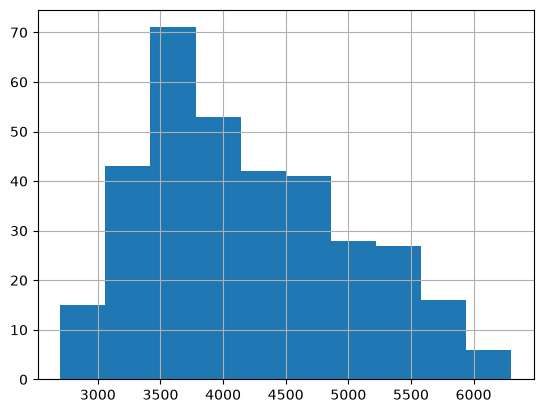

In [226]:
## show the distribution 
df_penguins['body_mass_g'].hist()

## IMG

In [227]:
import numpy as np
import matplotlib.pyplot as plt

## pip install opencv-python
import cv2

In [228]:
## read image
img = cv2.imread('../data/mandril.png')

## convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## show dimensions
img_rgb.shape

(480, 500, 3)

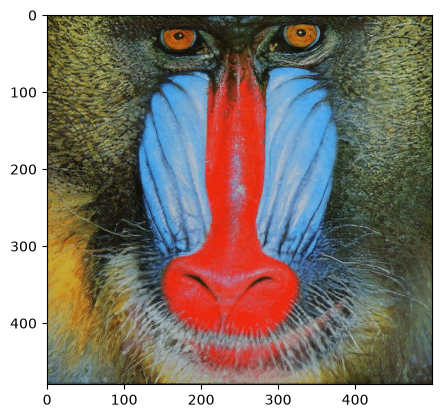

In [229]:
## show image
plt.imshow(img_rgb)
plt.show()

### Gray Conversion

In [230]:
## convert to grayscale
## gray -> 0.299*R + 0.587*G + 0.114*B
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

## show dimensions
img_gray.shape

(480, 500)

In [231]:
## resize the image
img_gray = cv2.resize(img_gray, (64, 64))

## show dimensions
img_gray.shape

(64, 64)

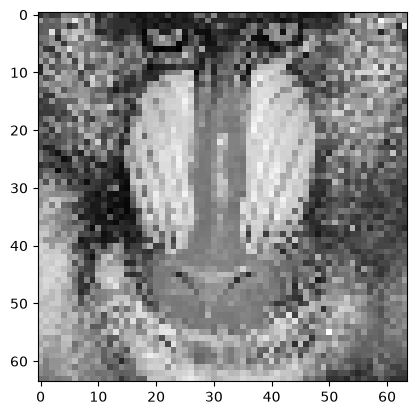

In [232]:
## show gray image
plt.imshow(img_gray, cmap='gray')
plt.show()

### Flattening

Suppose we have a 2D NumPy array:

```python
[
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
]
```

`flatten()` takes each row and places it after the previous one:

```text
Row 1 -> [1, 2, 3]
Row 2 ->          [4, 5, 6]
Row 3 ->                   [7, 8, 9]
```

The result is a 1D vector:

```python
[1, 2, 3, 4, 5, 6, 7, 8, 9]
```

In [233]:
## flatten the image
img_flatten = img_gray.flatten()
display(img_flatten)

## show dimensions
img_flatten.shape

array([44, 68, 52, ..., 46, 47, 48], shape=(4096,), dtype=uint8)

(4096,)

In [234]:
## reshape the vector for visualization
display(img_flatten.reshape(1, -1))

array([[44, 68, 52, ..., 46, 47, 48]], shape=(1, 4096), dtype=uint8)

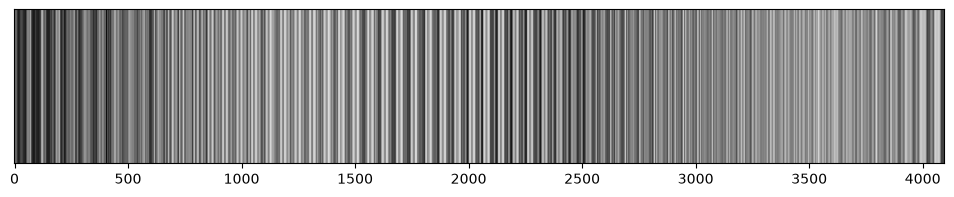

In [235]:
## show the flattened vector
plt.figure(figsize=(12, 2))
plt.imshow(img_flatten.reshape(1, -1), cmap='gray', aspect='auto')
plt.yticks([])
plt.show()

## PDF

In [236]:
import re

#!pip install pymupdf
import pymupdf

In [237]:
## open pdf
pdf = pymupdf.open('../data/Deep Learning - Nature.pdf')
pdf

Document('../data/Deep Learning - Nature.pdf')

In [238]:
## show metadata
metadata = pdf.metadata
metadata

{'format': 'PDF 1.6',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'creator': 'Adobe InDesign CC 2014 (Macintosh)',
 'producer': 'Adobe PDF Library 11.0',
 'creationDate': "D:20150521145735+01'00'",
 'modDate': "D:20150521145735+01'00'",
 'trapped': '',
 'encryption': None}

In [239]:
## show number of pages
print('Pages:', len(pdf))

Pages: 9


### Get Text

In [240]:
## get first page
page = pdf[0]

## extract text
text = page.get_text('text')
print(text[0:2000])

1Facebook AI Research, 770 Broadway, New York, New York 10003 USA. 2New York University, 715 Broadway, New York, New York 10003, USA. 3Department of Computer Science and Operations 
Research Université de Montréal, Pavillon André-Aisenstadt, PO Box 6128  Centre-Ville STN Montréal, Quebec H3C 3J7, Canada. 4Google, 1600 Amphitheatre Parkway, Mountain View, California 
94043, USA. 5Department of Computer Science, University of Toronto, 6 King’s College Road, Toronto, Ontario M5S 3G4, Canada.
M
achine-learning technology powers many aspects of modern 
society: from web searches to content filtering on social net­
works to recommendations on e-commerce websites, and 
it is increasingly present in consumer products such as cameras and 
smartphones. Machine-learning systems are used to identify objects 
in images, transcribe speech into text, match news items, posts or 
products with users’ interests, and select relevant results of search. 
Increasingly, these applications make use of a class

In [241]:
## extract text blocks
blocks = page.get_text('blocks')

for block in blocks:
    print(block)

(36.850399017333984, 723.6008911132812, 545.6761474609375, 748.048095703125, '1Facebook AI Research, 770 Broadway, New York, New York 10003 USA. 2New York University, 715 Broadway, New York, New York 10003, USA. 3Department of Computer Science and Operations \nResearch Université de Montréal, Pavillon André-Aisenstadt, PO Box 6128  Centre-Ville STN Montréal, Quebec H3C 3J7, Canada. 4Google, 1600 Amphitheatre Parkway, Mountain View, California \n94043, USA. 5Department of Computer Science, University of Toronto, 6 King’s College Road, Toronto, Ontario M5S 3G4, Canada.\n', 0, 0)
(35.76599884033203, 264.70806884765625, 72.83846282958984, 320.83685302734375, 'M\n', 1, 0)
(36.850399017333984, 275.660400390625, 291.32464599609375, 372.2060852050781, 'achine-learning technology powers many aspects of modern \nsociety: from web searches to content filtering on social net\xad\nworks to recommendations on e-commerce websites, and \nit is increasingly present in consumer products such as cameras 

In [242]:
## extract text following the visual reading order
text = page.get_text('text', sort=True)
print(text[0:2000])

                                                                                                                doi:10.1038/nature14539REVIEW

Deep learning
Yann LeCun1,2, Yoshua Bengio3 & Geoffrey Hinton4,5


  Deep learning allows computational models that are composed of multiple processing layers to learn representations of
  data with multiple levels of abstraction. These methods have dramatically improved the state-of-the-art in speech rec­
  ognition, visual object recognition, object detection and many other domains such as drug discovery and genomics. Deep
  learning discovers intricate structure in large data sets by using the backpropagation algorithm to indicate how a machine
  should change its internal parameters that are used to compute the representation in each layer from the representation in
  the previous layer. Deep convolutional nets have brought about breakthroughs in processing images, video, speech and
  audio, whereas recurrent nets have shone light on sequent

In [243]:
## extract text from all pages
for page_number, page in enumerate(pdf):
    
    ## extract text following the visual reading order
    text = page.get_text('text', sort=True)

    ## replace multiple whitespace characters with a single space
    text = re.sub(r'\s+', ' ', text).strip()

    print(f'Page {page_number + 1}')
    print(text[:130], '...')
    print('-' * 50)

Page 1
doi:10.1038/nature14539REVIEW Deep learning Yann LeCun1,2, Yoshua Bengio3 & Geoffrey Hinton4,5 Deep learning allows computational  ...
--------------------------------------------------
Page 2
REVIEW INSIGHT be seen as a kind of hilly landscape in the high-dimensional space of Many of the current practical applications of ...
--------------------------------------------------
Page 3
INSIGHT REVIEW Samoyed (16); Papillon (5.7); Pomeranian (2.7); Arctic fox (1.0); Eskimo dog (0.6); white wolf (0.4); Siberian husk ...
--------------------------------------------------
Page 4
REVIEW INSIGHT remainder29,30. The analysis seems to show that saddle points with this architecture is twofold. First, in array da ...
--------------------------------------------------
Page 5
INSIGHT REVIEW Vision Language Deep CNN Generating RNN A group of people shopping at an outdoor market. There are many vegetables  ...
--------------------------------------------------
Page 6
REVIEW INSIGHT context of ea

### Get Images

In [244]:
## get images from the pages
for page_number, page in enumerate(pdf):
    images = page.get_images()
    
    print(f'Number of images in Page {page_number + 1}:', len(images))

Number of images in Page 1: 0
Number of images in Page 2: 2
Number of images in Page 3: 136
Number of images in Page 4: 0
Number of images in Page 5: 13
Number of images in Page 6: 0
Number of images in Page 7: 0
Number of images in Page 8: 0
Number of images in Page 9: 0


In [245]:
# Get second page
page_2 = pdf[1]

## get images from the page
images = page_2.get_images()

print('Number of images:', len(images))

Number of images: 2


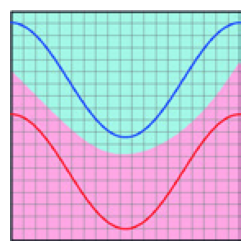

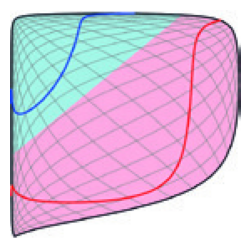

In [246]:
## extract and display each image
for image_info in images:
    ## get the image reference inside the PDF
    xref = image_info[0]

    ## extract image data
    image_data = pdf.extract_image(xref)

    ## extract image as bytes
    image_bytes = image_data['image']

    ## convert bytes to a numpy array
    image_array = np.frombuffer(image_bytes, dtype=np.uint8)

    ## decode the image
    image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    ## convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    ### show image
    plt.figure(figsize=(3, 3))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()